# Signal Analysis and Preprocessing

> A serious attempt at all the assignments is mandatory to grant access to the final exam. Refer to the course manual for more details (section *Overview* on Brightspace). 

> Please add today's topic to your knowledge graph.

**Learning goals:**
- Explore the wide range of neurotechnological applications that make use of neural oscillations
- Understand the difference between evoked responses (e.g. ERPs) and induced responses (e.g. oscillations)
- Get familiar with important signal analysis and (pre-)processing concepts like sampling frequency, Nyquist frequency, aliasing, detrending, spectral filtering, convolution, Hilbert transform, FFT, and spectrogram. 

**Solutions file:**

For this assignment, a solutions file will be released after the deadline.


# Exercise 1: Neurotechnology

Make a forum post about a neurotechnology application that uses oscillatory signals. Find an interesting neurotechnological application that uses neural oscillations (as opposed to evoked responses). Ideas about directions to search for are neuro- or motor-rehabilitation (e.g., the alpha/mu and beta rhythms), neurofeedback (e.g., the alpha and theta rhythms), or sleep studies (e.g., alpha, slow-wave sleep, deep sleep).
1. Find an interesting application of neurotechnology, post a link to it (e.g., the blog post, article, podcast, video, etc.) in the assignment forum of Week 08. Describe the application in a few sentences. As the subject of your posts, use a sensible title that explains the body. 
1. We encourage to comment on each other's posts and to answer each other's questions. Comment on at least one of the applications of other groups with interesting additional information or a critical question.


# Exercise 2: Setting up the data

We'll be looking at some EEG data related to an eyes open and eyes closed paradigm, to get familiar with certain pre-processing and datahandling concepts. 

1. Download the data from Brightspace
1. Load the data with the provided functions

In [1]:
import os
import mne
import scipy.fft as fft 
from scipy.signal import spectrogram, chirp, hilbert, butter, sosfilt, detrend
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.simplefilter(action='ignore', category=RuntimeWarning)
mne.set_log_level('WARNING')

np.random.seed(42)

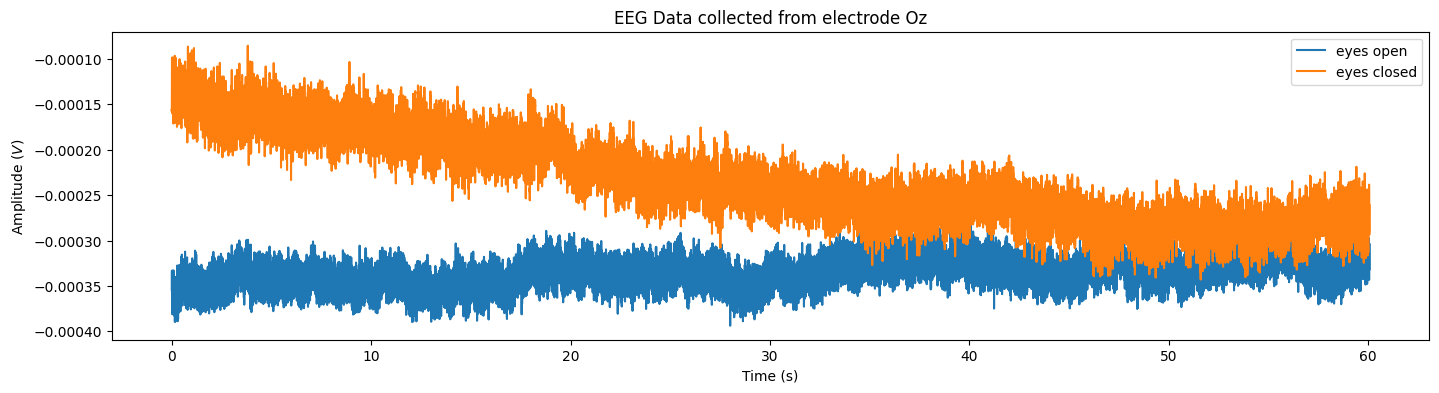

In [17]:
def load_and_preprocess_raw(header_file):
    non_eeg_channels = ["EOGvu", "x_EMGl", "x_GSR", "x_Respi", "x_Pulse", "x_Optic"]
    raw = mne.io.read_raw_brainvision(header_file, misc=non_eeg_channels, preload=True)
    raw.set_montage("standard_1020")
    raw.pick_types(eeg=True)
    return raw

# Load data
eyes_open = load_and_preprocess_raw(os.path.join(os.getcwd(), "data", "eyes_open.vhdr"))
eyes_closed = load_and_preprocess_raw(os.path.join(os.getcwd(), "data", "eyes_close.vhdr"))

# Visualize data
plt.figure(figsize=(17, 4))
plt.plot(eyes_open.times, eyes_open["Oz"][0].flatten(), label='eyes open')
plt.plot(eyes_closed.times, eyes_closed["Oz"][0].flatten(), label='eyes closed')
plt.legend()
plt.xlabel('Time (s)')
plt.ylabel('Amplitude ($V$)')
plt.title('EEG Data collected from electrode Oz')
plt.show()


# Exercise 3: Detrending the data

As you can see above, the data may sometimes exhibit a (linear) trend. In such cases it might be useful to (linearly) detrend the data. Fortunately, that is an easy thing to do, using the `detrend()` function from the `scipy.signal` library.
1. Detrend the data (a single channel and epoch is enough)
1. Plot the detrended data
1. What are potential reasons for trends in the data? Name at least 3 possible reasons
1. Explain in your own words what (linear) detrending does.

<RawBrainVision | eyes_open.eeg, 63 x 60080 (60.1 s), ~29.0 MB, data loaded> 
 <RawBrainVision | eyes_close.eeg, 63 x 60080 (60.1 s), ~29.0 MB, data loaded>


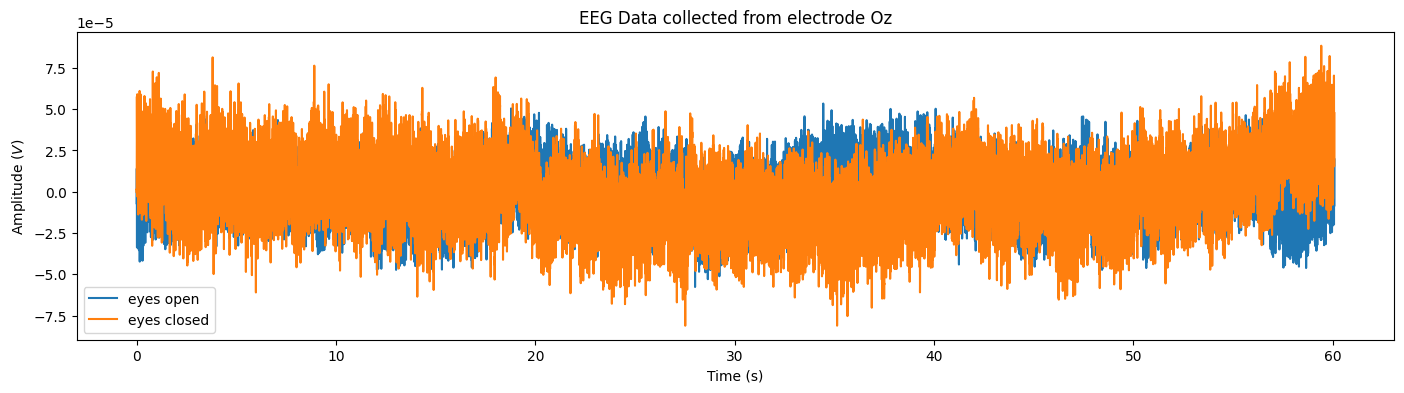

In [18]:
# Answer here
from scipy.signal import detrend
print((eyes_open),'\n',(eyes_closed))
dtd_eyes_open = detrend(eyes_open["Oz"][0].flatten(), type='linear')
dtd_eyes_closed = detrend(eyes_closed["Oz"][0].flatten(), type='linear')
# print(eyes_open["Oz"][0])
# print(eyes_open.times)

plt.figure(figsize=(17, 4))
plt.plot(eyes_open.times, dtd_eyes_open, label='eyes open')
plt.plot(eyes_closed.times, dtd_eyes_closed, label='eyes closed')
plt.legend()
plt.xlabel('Time (s)')
plt.ylabel('Amplitude ($V$)')
plt.title('EEG Data collected from electrode Oz')
plt.show()


3. Possible reasons for trends in the data can be the gel between the scalp and electrodes drying up or an error in a system or the headcap being move due to a head movement of the subject.
4. Linear detrending removes a straight line to the data that comes from fitting a linear regression on it and detecting the steady increasing or decreasing behaviour. Then it substracts it. 

# (Optional) Exercise 4: Convolution

Though we aren't making explicit use of it in this assignment, you should be familiar with the mathematical operation *convolution*. Check out these resources for a refresher:
* [Convolution on Wikipedia](https://en.wikipedia.org/wiki/Convolution)
* [Mike Cohen's great YouTube video on convolution](https://youtu.be/9Hk-RAIzOaw)

1. Explain in your own words what convolution is.

In [19]:
# Answer here

# Exercise 5: Sampling rate and the Shannon-Nyquist Theorem.

Back in Applied Mathematics you were introduced to the basics of signal analysis. An important concept is the sampling frequency. Firstly, it is required that you understand the [Shannon-Nyquist sampling theorem](https://home.strw.leidenuniv.nl/~por/AOT2019/docs/AOT_2019_Ex13_NyquistTheorem.pdf).

In a few words, explain:
1. What sampling frequency means and what is the sampling frequency of the data in this assignment;
1. What the Nyquist frequency entails and what is the specific value for our data;
1. What aliasing is and what the frequency range in our data is where we might be experiencing aliasing;
1. How to prevent aliasing.

### Answer here
1. Sampling frequency is the amount of samples that are taken in a second and in this assignment it is fs = 1000 Hz.
2. The Nyquist is the highest possible frequency that it can be accurately represented with our data and it is always equal to half the sampling frequency $$ f_{Ny} = f_s/2 $$
3. Aliasing is when a higher frequency is camouflaged as a lower frequency that is non-existent in the original data and happens when the signal is sampled too slowly (sampling rate is below Nyquist rate).
4. To prevent aliasing you have to bandpass or low-pass filter the frequencies above the Nyquist frequency to be excluded from the signal.

# Exercise 6: Spectral analysis

We can analyze the frequency contents of a signal, that is - the frequencies that make up the signal, by computing its frequency spectrum. One of the most common ways to do that is by using the Fast Fourier Transform (FFT), that you have learned about in Applied Mathematics. If you need a refresher here is a nice [video about it](https://youtu.be/spUNpyF58BY). For additional appreciation of the beauty behind the Fourier series we also recommend [this other video](https://youtu.be/r6sGWTCMz2k).

1. Use the numpy or scipy functions `rfft` and `rfftfreq` (the scipy implementation is built on top of numpy so these are equivalent) to obtain the frequency response and frequency range of the `eyes_open` data. Then, plot them to observe the frequency spectrum. It is up to you which channel you want to work with.
2. Observe that there is a large peak at around 50Hz. Can you explain what caused this peak? **Tip**: it's not because of the participant's brain.
3. How can we remove this frequency component? **Tip**: if you can't think of a solution, finish the notebook and come back to this question later.
4. Note that we also need a sufficient amount of data points to obtain a nice frequency resolution. This can be demonstrated by running the FFT on a tiny time window from our data. Do this by running the procedure from the first subexercise on a tiny portion (equal to a 16th) of the data. Compare the newly obtained spectrum to the original one. You should be able to see spectral leakage happening in the frequency spectrum obtained from less samples (e.g. easily apparent at the 50Hz spike) **Tip**: if you can't see the difference immediately, try zooming in on the first 60 frequencies.

We've provided you with 2 recordings - one where the participant had their eyes open (`eyes_open` variable) and one with their eyes were closed (`eyes_closed` variable). 

5. What difference do you expect to see in the spectral content of the 2 recordings?
6. Plot the frequency spectrum of a single channel for each of the two conditions. Is the answer you gave to the previous question in line with what you see? **Tip:** carefully think about which channel to visualize!

The frequency spectrum we plotted shows how much each frequency contributes to the entirity of the signal. However it is not the case that at each **time point** their contribution was equal. In order to capture spectro-temporal characteristic, we may want to instead compute the spectrogram. A spectro-gram is a time-frequency representation (TFR) that, as the name suggests, gives us information about the frequency spectrum at different time points.

7. Use the `spectrogram` function, provided by the `scipy.signal` library to easily compute the spectrogram of the whole signal. Do this for the eyes closed condition. 
8. Plot the spectrogram. What do you observe?


[-0.0003542 -0.0003535 -0.0003494 ... -0.0003179 -0.0003248 -0.0003316]
1000.0


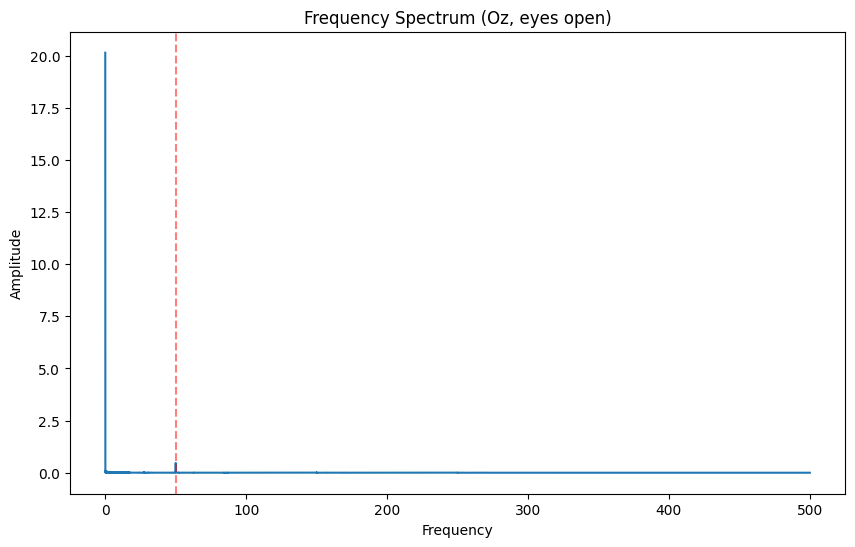

In [20]:
# Answer here
print((eyes_open["Oz"][0].flatten()))
print(eyes_open.info['sfreq'])

eyes_open_data = eyes_open["Oz"][0].flatten()
fs = eyes_open.info['sfreq']
eyes_open_fft = np.fft.rfft(eyes_open_data)
freqs = np.fft.rfftfreq(len(eyes_open_data), d=1/fs)
eyes_open_spectrum = np.abs(eyes_open_fft)
# eyes_open_power = np.abs(eyes_open_fft)**2

plt.figure(figsize = (10,6))
plt.plot(freqs, eyes_open_spectrum)
plt.xlabel('Frequency')
plt.axvline(x=50, color='r', label= "Power line artifact", alpha = 0.5, linestyle = '--')
plt.ylabel('Amplitude')
plt.title("Frequency Spectrum (Oz, eyes open)")
plt.show()
# print(eyes_open.times)
# plt.plot(freqs)

2. The 50 Hz peak is an electric artifact caused by the interference from the 50 Hz electrical activity in Europe (60 Hz in USA) that runs through wires.
3. We can use a spectral filter (next exercise)

First 3755 samples


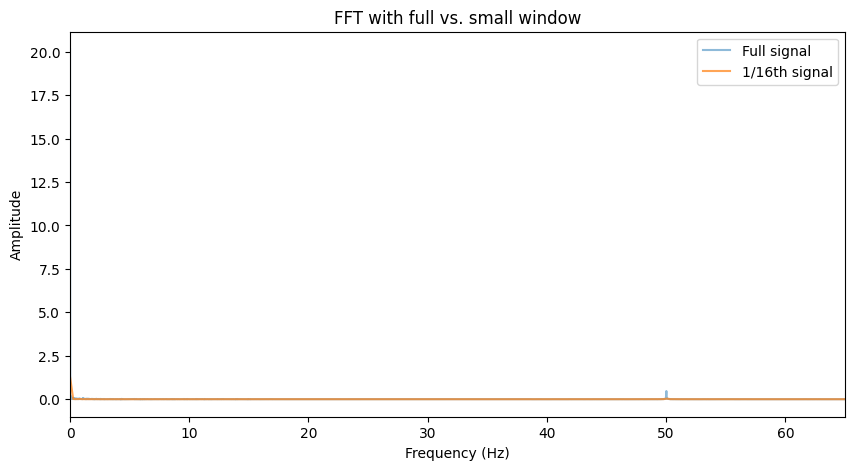

In [ ]:
# 4) Take the full signal first
signal_full = eyes_open["Oz"][0].flatten()
fs = eyes_open.info['sfreq']  # sampling frequency

# Get the first 1/16th of the signal
portion = 1/16
n_samples_small = int(len(signal_full) * portion)
print(f"First {n_samples_small} samples")
signal_small = signal_full[:n_samples_small]

# Compute FFTs
fft_full = np.fft.rfft(signal_full)
fft_small = np.fft.rfft(signal_small)

# Corresponding frequency axes
freq_full = np.fft.rfftfreq(len(signal_full), d=1/fs)
freq_small = np.fft.rfftfreq(len(signal_small), d=1/fs)

# Plot to compare
plt.figure(figsize=(10,5))
plt.plot(freq_full, np.abs(fft_full), label='Full signal', alpha=0.5)
plt.plot(freq_small, np.abs(fft_small), label='1/16th signal', alpha=0.7)
plt.xlim(0, 65)  # zoom in to see spectral leakage around 50 Hz
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.title('FFT with full vs. small window')
plt.legend()
plt.show()

# We can that the 1/16 window does properly 
# portray the electric artifact peak at 50 Hz

5. We expect to see a peak in the occipital region (channel Oz) in the alpha frequency band (8-12 Hz) in the eyes closed condition. In the case of eyes open the peak usually dissapears due to event-related desynchronization. 

# (optional) Exercise 7: Other time-frequency analysis methods:
There are other methods to compute a frequency spectrum or a time-frequency representation, such as:
* [Wavelets on Wikipedia](https://en.wikipedia.org/wiki/Wavelet),
* [Morlet wavelets on Mike Cohen's YouTube channel](https://youtu.be/7ahrcB5HL0k),
* [Auto regressive models on Wikipedia](https://en.wikipedia.org/wiki/Autoregressive_model).

*These are recommended to know about, but **not required materials**.*

1. Reproduce the analysis of Exercise 6., but use the other methods presented above instead of the Fast Fourier Transform.   

In [ ]:
# Answer here

# Exercise 8: Spectral Filters

[Spectral filters](https://atmos.washington.edu/~breth/classes/AM582/lect/lect12-notes.pdf) can be used to discard spectral data that we're not interested in (e.g. that nasty 50Hz powerline noise). They work by filtering out the spectral power at a certain chosen frequency range while retaining all the information outside of that range. A high-pass filter retains higher frequencies (lets them through/lets them *pass*), while a low-pass filter does the opposite. A band-pass filter removes all frequencies outside a specified band and a band-stop filter removes only the frequencies inside the stop-band. The stop-band filter is also called a Notch filter when the stop band is relatively narrow; for example: the range [48Hz - 52Hz] surrounding the 50Hz powerline noise.

Spectral filters are first *designed* according to the sampling rate of the data they will be applied on and the response curve we want from that filter. The response curve describes how well the filter preserves frequencies inside the desired band and how well it removes frequencies outside the desired band. There are multiple filter types, but the [Butterworth filter](https://en.wikipedia.org/wiki/Butterworth_filter) is the most commonly used one, as it has a maximally flat (i.e has no ripples, see picture) response curve in the passband and rolls off towards zero in the stopband. 

<img src="data/ripple.png" width="450" align="center" alt="Different filter types, showcasing the ripple effect"/>

[Source](https://en.wikipedia.org/wiki/Butterworth_filter)

Finally, filters have an important property called *order*. In short: the higher the order the closer you get to the ideal "Brick wall" (i.e. square wave) response curve, where a filter would perfectly remove the power of all frequencies outside the desired band and keep all frequencies in the desired band unchanged. Of course, this does not come without a cost - higher order filters are more computationally heavy (in software this requires more processing power, in hardware - more physical components) and are prone to becoming unstable. The figure below demonstrates how the response of the Butterworth filter changes with order.

<img src="data/butter.png" width="450" align="center" alt="Filter response"/>

[Source](https://www.electronics-tutorials.ws/filter/filter_8.html)

We've provided an example where we create sinusoids with frequencies from 5 to 100 Hz, after which we filter out the ones above 16 Hz. 
1. Do the same for the EEG signal (e.g. open condition). Note that such filtering will also take out the 50 Hz powerline noise.Experiment with different filter orders and stopband/passband sizes. **Tip:** plot the frequency spectrum before and after applying the spectral filter.

It is important to note that spectral filters are not a magical tool that instantly work perfectly. Spectral filters always have a 'warm-up' period, where they need to observe some data before they kick in and start removing frequencies properly. This is relevant to us, as BCI experts, as we often like to slice our data into epochs. If we were to apply the filter on every tiny epoch, then we will experience this warm-up behaviour on every single epoch. This is why you should preferably filter your data before slicing it into epochs or alternatively apply zero-padding/grabbing more data than neccessary for each epoch, such that your filter can warm up on data you can discard.

Finally, an import note here. So far we have come across two different filtering methods: spatial ones and spectral (i.e., frequency) ones. Make sure you understand the differences between these two, what they are used for, and how they work!

In [ ]:
# Example

example_duration = 1.0
example_fs = 200.0
example_N_samples = int(example_fs*example_duration)
example_time = np.arange(example_N_samples) / example_fs

# Create dummy signal with sinusoids from 5 to 100 Hz
example_signal = np.zeros(example_N_samples)
for freq in range(5,100):
    amp_coef = np.random.rand()
    if freq==50:
        # amplify the 50Hz component to simulate a powerline noise
        amp_coef = 3
    # randomly amplify a randomly phase-shifted sinusoid
    example_signal += amp_coef * np.sin(2*np.pi*freq*example_time + np.random.rand()*2*np.pi)


fig, ax = plt.subplots(3, 2, figsize=(12,18))

ax[0][0].plot(example_time, example_signal)
ax[0][0].axis([0, 1, -20, 20])
ax[0][0].axhline(0,0,1, c='k',linewidth=0.5,zorder=0)
ax[0][0].set_title('5 Hz to 100 Hz sinusoids')
ax[0][0].set_ylabel('Amplitude')

ax[0][1].plot(fft.rfftfreq(example_N_samples,1/example_fs), abs(fft.rfft(example_signal)))
ax[0][1].set_title('Frequency Spectrum of 5 Hz to 100 Hz sinusoids')
ax[0][1].set_ylabel('Response')

# Apply Butterworth Low-pass Filter of 2nd order
sos2 = butter(2, 16, 'lp', fs=example_fs, output='sos')
filtered2 = sosfilt(sos2, example_signal)

ax[1][0].plot(example_time, filtered2)
ax[1][0].axhline(0,0,1, c='k',linewidth=0.5 ,zorder=0)
ax[1][0].axis([0, 1, -20, 20])
ax[1][0].set_title('After 2nd order 16 Hz low-pass filter')
ax[1][0].set_ylabel('Amplitude')

ax[1][1].plot(fft.rfftfreq(example_N_samples,1/example_fs), abs(fft.rfft(filtered2)))
ax[1][1].set_title('Frequency spectrum after 2nd order\n 16 Hz low-pass filter')
ax[1][1].set_ylabel('Response')

# Apply Butterworth Low-pass Filter of 10th order
sos10 = butter(10, 16, 'lp', fs=example_fs, output='sos')
filtered10 = sosfilt(sos10, example_signal)

ax[2][0].plot(example_time, filtered10)
ax[2][0].axhline(0,0,1, c='k',linewidth=0.5 ,zorder=0)
ax[2][0].axis([0, 1, -20, 20])
ax[2][0].set_title('After 10th order 16 Hz low-pass filter')
ax[2][0].set_xlabel('Time [seconds]')
ax[2][0].set_ylabel('Amplitude')

ax[2][1].plot(fft.rfftfreq(example_N_samples,1/example_fs), abs(fft.rfft(filtered10)))
ax[2][1].set_title('Frequency spectrum after 10th order\n 16 Hz low-pass filter')
ax[2][1].set_xlabel('Frequencies [Hz]')
ax[2][1].set_ylabel('Response')

plt.show()

In [ ]:
# Answer here

# Exercise 9: Hilbert Transform

Event-related potentials (ERPs) are phase-locked signals, meaning we know when to expect peaks in the signal (after stimulus onset), which allows us to average over multiple epochs to get a better estimation of an ERP's shape. Neural oscilations, on the other hand, are phenomena that are typically not phase locked. This means that we can't average them directly, as they might be in antiphase (negative peaks of one epoch coincide with positive peaks of another), resulting in an uninformative sum close to 0 (because they cancel each other out). For oscillations, instead of averaging in the time-domain to obtain ERPs, one would instead average in the frequency-domain to obtain event-releated spectral pertubations (ERsP). 

1. Explain in you own words how averaging helps removing noise in the time-domain to extract ERPs, and how it helps to clean-up noise in the frequency-domain to extract ERsPs.

Another way of working with (single-trial, non-averaged) oscillations is by looking at the [envelope](https://en.wikipedia.org/wiki/Envelope_(waves)) of a signal, instead of the signal itself. We can calculate the envelope using the [Hilbert transform](https://www.gaussianwaves.com/2017/04/extract-envelope-instantaneous-phase-frequency-hilbert-transform/). We recommend this [video](https://youtu.be/jy7IxIXUAJk) for a deeper understanding of the Hilbert transform.

2. Use the `hilbert` function provided by the `scipy.signal` library in order to calculate the envelope of the toy signal below and plot the signal together with its envelope.

In [ ]:
duration = 1.0
fs = 400.0
samples = int(fs*duration)
t = np.arange(samples) / fs

# Generate a sinusoid that starts at 20hz and increases to 100hz over 1 second
signal = chirp(t, 20.0, t[-1], 100.0) 

# Some amplitude modulation to get an envelope that isn't just a straight line
signal *= (1.0 + 0.5 * np.sin(2.0*np.pi*3.0*t) ) 

# Visualize
plt.figure(figsize=(15, 3))
plt.plot(t, signal, label = "signal")
plt.axhline(0, c='k')
plt.ylabel('Amplitude')
plt.xlabel('Time (s)')
plt.title('An example oscillatory signal')
plt.legend()


In [ ]:
# Answer here

# Exercise 10: Further remarks on preprocessing and MNE

Throughout this assignment you have learned about important concepts from signal analysis and how they are used for preprocessing and feature extraction in BCIs. This was not at all an exhasutive list. Typical propreccising steps involve:
- Re-referencing: common-average-referencing (CAR), Laplacian, mastoid referencing, etc. (note, kind of non-learned spatial filter)
- Detrending (note, detrending is also achieved by applying a high-pass filter)
- Spectral filter: low-pass, high-pass, band-pass, band-stop (notch)
- Resampling: e.g. downsampling the data to a lower sampling frequency
- Data cleaning: e.g., removing eye blinks with ICA
- Outlier removal: e.g., removing channels/trials/epochs
- Baselining: removing means (of a baseline period) from individual epochs

Throughout this assignment you have been using numpy and scipy functionality to preprocess and analyse the data. These routines are typically easy to work with. However, MNE provides functionality for preprocessing routines as well as many analysis methods. These make analysing BCI data even easier! 

1. Inspect the code snippet below that uses some MNE tools.
2. Make a list of (examples of) MNE functions that implement the steps listed above.

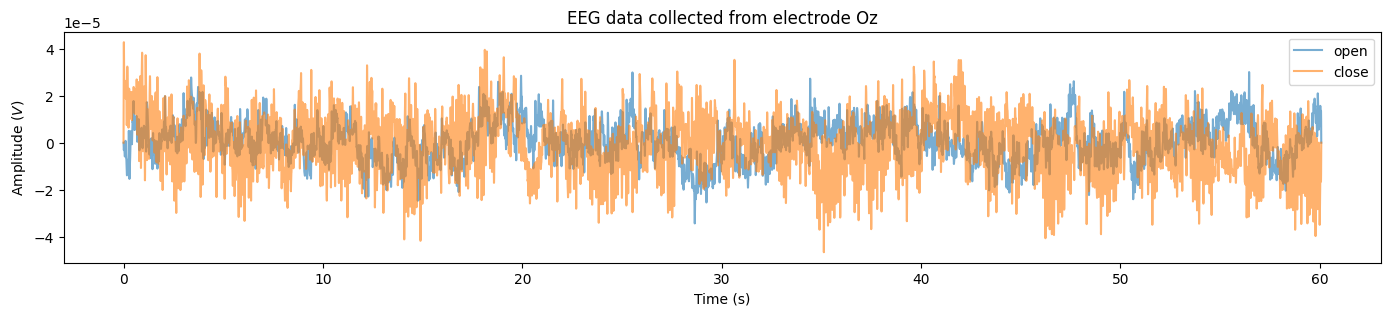

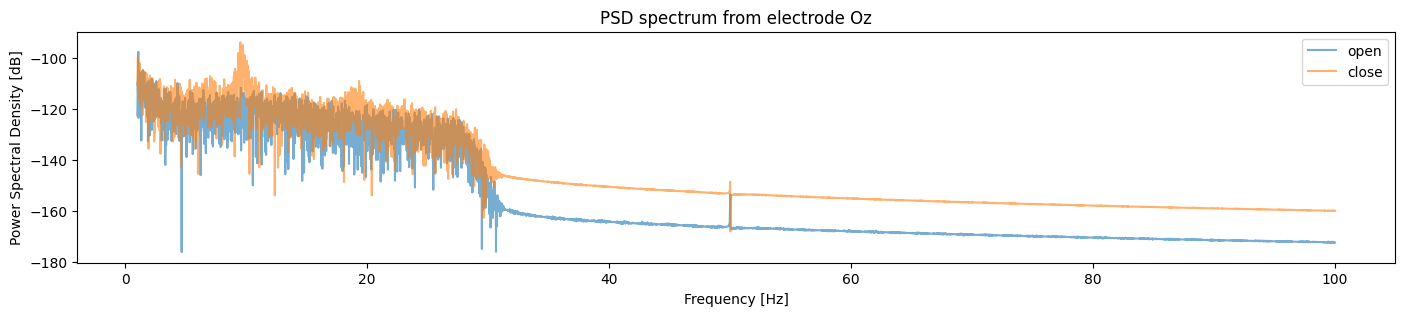

In [13]:
# Apply a band-pass
_eyes_open = eyes_open.filter(l_freq=0.1, h_freq=25, verbose=False)
_eyes_closed = eyes_closed.filter(l_freq=0.1, h_freq=25, verbose=False)

# Visualize the first epoch of both conditions
plt.figure(figsize=(17, 3))
plt.plot(_eyes_open.times, _eyes_open['Oz'][0].flatten(), label='open', alpha=0.6)
plt.plot(_eyes_closed.times , _eyes_closed['Oz'][0].flatten(), label='close', alpha=0.6)
plt.legend()
plt.xlabel('Time (s)')
plt.ylabel('Amplitude ($V$)')
plt.title('EEG data collected from electrode Oz')

# Compute PSD
tmin = 0.
tmax = 60.
fmin = 1.
fmax = 100.

psds_open, freqs_open = mne.time_frequency.psd_array_welch(_eyes_open["Oz"][0], sfreq=_eyes_open.info['sfreq'],
    n_fft=int(_eyes_open.info['sfreq'] * (tmax - tmin)), fmin=fmin, fmax=fmax, window='boxcar', verbose=False)
psds_close, freqs_close = mne.time_frequency.psd_array_welch(_eyes_closed["Oz"][0], sfreq=_eyes_closed.info['sfreq'],
    n_fft=int(_eyes_closed.info['sfreq'] * (tmax - tmin)), fmin=fmin, fmax=fmax, window='boxcar', verbose=False)

# Visualize PSD
plt.figure(figsize=(17, 3))
plt.plot(freqs_open, 10 * np.log10(psds_open.flatten()), label="open", alpha=0.6)
plt.plot(freqs_close, 10 * np.log10(psds_close.flatten()), label="close", alpha=0.6)
plt.legend()
plt.title("PSD spectrum from electrode Oz")
plt.xlabel('Frequency [Hz]')
plt.ylabel('Power Spectral Density [dB]')
plt.show()

## Exercise 0: Who did what?
Please provide a short description on who contributed what to your submission.

> Answer here